# NAC playground

This file can be used to perform minor experiments related to NAC-coloring search.

Make sure the `nac` directory is in your working directory, and that you installed `requirements.txt` into your virtual environment.

In [1]:
from typing import *
import importlib

import pyrigi
import nac as nac
import nac.util
from nac import MonochromaticClassType
from benchmarks import datasets
importlib.reload(nac)
importlib.reload(nac.util)
importlib.reload(datasets)

seed=42

In [2]:
class Strategies:
    NAIVE = "naive"
    CYCLES = "cycles"
    NONE_LINEAR = 'subgraphs-linear-none-6'
    NEIGHBORS_LINEAR = 'subgraphs-linear-neighbors-6'
    NEIGHBORS_DEGREE_LINEAR = 'subgraphs-linear-neighbors_degree-6'
    NEIGHBORS_SHARED_VERTICES = 'subgraphs-shared_vertices-neighbors-6'

`pyrigi.graphDB` provides a great collection of graphs useful for testing

In [3]:
G = pyrigi.graphDB.ThreePrism()

In [4]:
display(nac.has_NAC_coloring(G))

coloring = nac.single_NAC_coloring(G)
display(coloring)

True

([(0, 1), (0, 2), (1, 2), (3, 4), (3, 5), (4, 5)], [(0, 3), (1, 4), (2, 5)])

In [5]:
colorings = list(nac.NAC_colorings(
    G,
    algorithm=Strategies.NEIGHBORS_LINEAR,
))
display(colorings)

[([(0, 1), (0, 2), (1, 2), (3, 4), (3, 5), (4, 5)], [(0, 3), (1, 4), (2, 5)]),
 ([(0, 3), (1, 4), (2, 5)], [(0, 1), (0, 2), (1, 2), (3, 4), (3, 5), (4, 5)])]

In [6]:
def with_colors(coloring: nac.NACColoring):
    return {
        "red": coloring[0],
        "blue": coloring[1],
    }

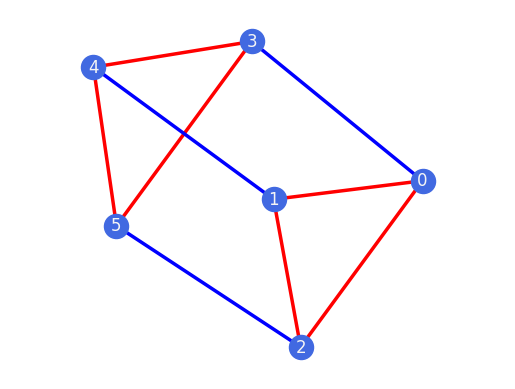

In [7]:
G.plot(edge_colors_custom=with_colors(coloring))